In [1]:
from pathlib import Path

def data_dir() -> Path:
    """หาโฟลเดอร์ datasets/ โดยไล่ขึ้นจาก cwd."""
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p / "datasets").exists():
            return p / "datasets"
    raise SystemExit("ไม่พบโฟลเดอร์ datasets/ — เปิด JupyterLab จาก repo root (uv run jupyter lab)")

DATA = data_dir()

# # Module 6 — Clustering: หา operating regimes ของเครื่องมือวัด
#
# **Dataset (โปรดอ่านก่อนใช้งาน):**
#
# - *Air Quality* — De Vito, S., Massera, E., Piga, M., Martinotto, L., Di Francia, G. (2008). "On field calibration of an electronic nose for benzene estimation in an urban pollution monitoring scenario", *Sensors and Actuators B: Chemical*, 129(2), 750–757; *Air Quality* [Data set]. UCI Machine Learning Repository. https://doi.org/10.24432/C59K5F (CC BY 4.0)
#
# ไฟล์: `datasets/air_quality_uci.csv`
#
# **ปูมหลังที่ต้องรู้ (จาก Day 1):** เราเคย parse ไฟล์นี้แล้วในโมดูล Workflow & EDA — เครื่องหมายคั่นคือ `;` ทศนิยมเป็น **comma** (ยุโรป) และค่าที่เซนเซอร์พังถูกแท็กเป็น **-200** — และเราเคยเห็นแล้วว่า **scaling ก่อนใช้ distance-based method เป็นขั้นตอนบังคับ** วันนี้เราจะใช้ทั้งสองบทเรียนนั้นจริงจัง
#
# **เรื่องราวเมโทรโลยีของโมดูลนี้:** เซนเซอร์ก๊าซ metal-oxide หนึ่งตัว (5 ช่องสัญญาณ PT08.S1–S5) ถูกติดตั้งกลางเมืองอิตาลี วัดทุกชั่วโมงติดต่อกันเกือบปี (มี.ค. 2004 – เม.ย. 2005) พร้อมอุณหภูมิ `T` และความชื้นสัมพัทธ์ `RH` — ปัญหาเมโทรโลยีคือ **เครื่องมือเดียวกันไม่ตอบสนองเท่ากันในทุกสภาพแวดล้อม** ความร้อนและความชื้นเปลี่ยนการตอบสนองของเซนเซอร์ เราจะให้ clustering หาว่าข้อมูลมี **operating regimes** กี่แบบ (เช่น กลางวันร้อน-แห้ง กับ กลางคืนเย็น-ชื้น) เพื่อที่ห้องปฏิบัติการสอบเทียบจะได้จัดการแต่ละ regime แยกกัน — และใช้ DBSCAN จับช่วงเวลาที่ "ไม่อยู่ใน regime ไหนเลย" (สภาพแวดล้อมผิดปกติ)
#
# แผนของโมดูล: parse → scale → K-Means (เลือก k ด้วย elbow + silhouette) → มอง cluster ผ่าน PCA → DBSCAN → เช็กว่า regime ตรงกับฤดูกาล/รอบวันหรือไม่

# ## 1. โหลดและ parse — ย่อจาก Day 1 เป็นสี่บรรทัด

# ทำเหมือนที่เคยทำละเอียดแล้วในโมดูล Workflow & EDA: อ่านด้วย `;`, แท็ก -200 เป็น null ตั้งแต่ประตู, แปลงทศนิยม comma เป็น float, รวม `Date`+`Time` เป็น timestamp แล้ว **ทิ้งแถวที่มี null ใน 7 คอลัมน์ที่ใช้ cluster** (5 ช่อง PT08 + T + RH) — clustering ใช้ระยะทางไม่ได้กับค่าว่าง

In [2]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

aq = pl.read_csv(DATA / "air_quality_uci.csv", separator=";", null_values="-200")
aq = aq.filter(pl.col("Date").is_not_null())          # ทิ้งแถวว่างท้ายไฟล์
for c in ["CO(GT)", "C6H6(GT)", "T", "RH", "AH"]:      # ทศนิยม comma → float
    aq = aq.with_columns(pl.col(c).str.replace(",", ".").cast(pl.Float64))
aq = aq.with_columns(
    (pl.col("Date") + " " + pl.col("Time")).str.to_datetime("%d/%m/%Y %H.%M.%S").alias("ts")
)

FEATURES = ["PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)",
            "PT08.S4(NO2)", "PT08.S5(O3)", "T", "RH"]
clean = aq.drop_nulls(FEATURES).with_row_index("row_id")

print(f"แถวที่อ่านได้ (มี Date): {aq.height}")
print(f"แถวที่ใช้ cluster ได้ (ไม่มี null ใน 7 คอลัมน์): {clean.height}")
print(f"ช่วงเวลา: {clean['ts'].min()} → {clean['ts'].max()}")

แถวที่อ่านได้ (มี Date): 9357
แถวที่ใช้ cluster ได้ (ไม่มี null ใน 7 คอลัมน์): 8991
ช่วงเวลา: 2004-03-10 18:00:00 → 2005-04-04 14:00:00


# เหลือ **8,991 ชั่วโมง** จาก 9,357 — แถวที่หายไป 366 แถวคือช่วงเดียวกันที่ทั้ง 7 คอลัมน์เป็น -200 (เซนเซอร์หยุดบันทึก) ซึ่งเราเคยสำรวจไปแล้วใน Day 1
#
# Feature ที่ใช้: 5 ช่องสัญญาณเซนเซอร์ (ค่า ADC ของ metal-oxide ช่วง ~200–2,800) + `T` (°C, ~−2 ถึง 45) + `RH` (%, ~9 ถึง 89) — สังเกตว่าหน่วยกับสเกลต่างกันคนละโลก ซึ่งพาไปสู่หัวข้อถัดไป

# ## 2. ทำไมต้อง scale ก่อน K-Means — ระยะทางถูกขนาดข้อมูลข่ม

# K-Means วัด "ความใกล้" ด้วยระยะทางยุคลิดในหน่วยดิบ — คอลัมน์ที่ค่าเบิ้มกว่าจะครองการคำนวณทั้งหมด ดูสเกลของแต่ละคอลัมน์ในหนึ่งภาพ (ใช้ค่า std เป็นตัวชี้ "ความกว้าง" ของแต่ละแกน)

/tmp/ipykernel_45222/2797443955.py:11: UserWarning: Glyph 3627 (\N{THAI CHARACTER HO HIP}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45222/2797443955.py:11: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45222/2797443955.py:11: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45222/2797443955.py:11: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45222/2797443955.py:11: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45222/2797443955.py:11: UserWarning: Glyph 3610 (\N{THAI CHARACTER BO BAIMAI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45222/2797443955.py:11: UserWarning: Glyph 3586 (\N{THAI CHARACTER KHO KHAI}) missing from font(s) DejaVu 

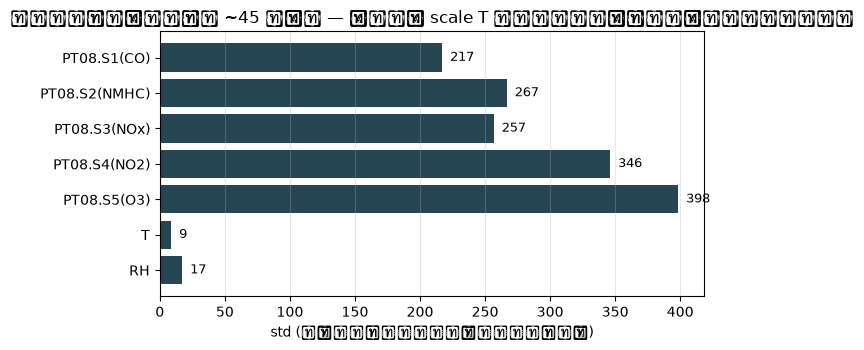

In [3]:
stds = clean.select(FEATURES).std().row(0)

fig, ax = plt.subplots(figsize=(7, 3.6))
bars = ax.barh(FEATURES[::-1], stds[::-1], color="#264653")
for b, v in zip(bars, stds[::-1]):
    ax.text(b.get_width() + 6, b.get_y() + b.get_height() / 2, f"{v:.0f}",
            va="center", fontsize=9)
ax.set_xlabel("std (หน่วยดิบของแต่ละคอลัมน์)")
ax.set_title("สเกลดิบต่างกัน ~45 เท่า — ถ้าไม่ scale T จะแทบไม่มีผลต่อระยะทาง")
ax.grid(alpha=0.3, axis="x")
fig.tight_layout()
plt.show()

# std ของช่อง PT08 อยู่ราว 217–398 หน่วย แต่ `T` มี std เพียง 8.8 องศา — ในการคำนวณระยะทางแบบยุคลิด (ผลต่างกำลังสองรวมกัน) อุณหภูมิจึงถูก "กลืน" แทบไม่เหลือน้ำหนัก ทั้งที่ในเชิงเมโทรโลยี T คือตัวแปรที่เราสนใจที่สุด
#
# ทางแก้: `StandardScaler` — ลบ mean หาร std ทีละคอลัมน์ ทุก feature จะมี std = 1 เท่ากันหมด และเราจะใช้ข้อมูล scaled นี้กับทุกอัลกอริทึมที่เหลือของโมดูล

In [4]:
from sklearn.preprocessing import StandardScaler

X = clean.select(FEATURES).to_numpy().astype(float)
scaler = StandardScaler().fit(X)
Xs = scaler.transform(X)          # รูปทรง (8991, 7) — หน่วยเป็น "จำนวน std จากค่าเฉลี่ย"

print("std หลัง scale:", np.round(Xs.std(axis=0), 3))

std หลัง scale: [1. 1. 1. 1. 1. 1. 1.]


# ## 3. K-Means — แบ่งพื้นที่การวัดเป็น regime และเลือก k

# K-Means ถามเราว่า "จะแบ่งกี่ regime?" — ไม่มีคำตอบสำเร็จรูป เราใช้เกณฑ์คู่:
#
# - **Inertia** (ผลรวมกำลังสองระยะทางจุด→centroid ของตัวเอง) ยิ่งน้อยยิ่งแน่น แต่ลดแบบ monotonically เมื่อ k เพิ่ม — เรามองหา **จุดศอก (elbow)** ที่หลังจากนั้นการเพิ่ม k ไม่ได้อะไร
# - **Silhouette** (−1 ถึง 1) วัดว่าจุดอยู่ใกล้ "พวกตัวเอง" กว่า "เผ่าข้างเคียง" แค่ไหน — สูง = แบ่งแล้วแยกชัด

/tmp/ipykernel_45222/1876316575.py:22: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45222/1876316575.py:22: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45222/1876316575.py:22: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45222/1876316575.py:22: UserWarning: Glyph 3621 (\N{THAI CHARACTER LO LING}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45222/1876316575.py:22: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45222/1876316575.py:22: UserWarning: Glyph 3594 (\N{THAI CHARACTER CHO CHANG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45222/1876316575.py:22: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaV

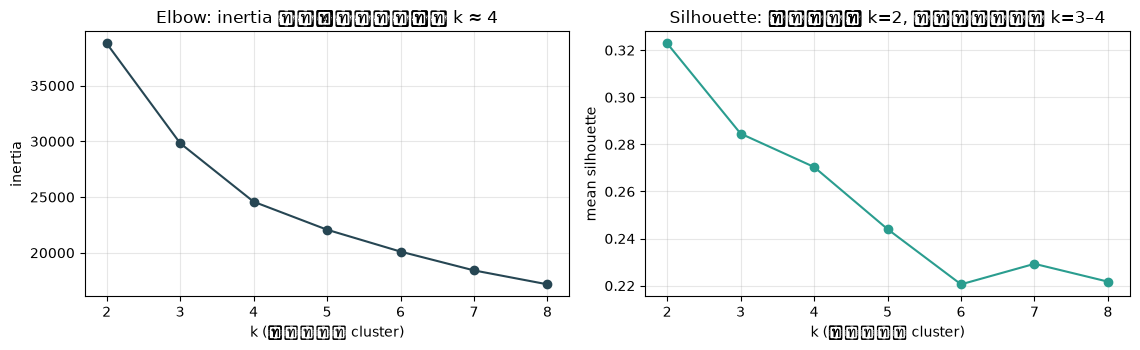

silhouette ราย k: {2: np.float64(0.3229), 3: np.float64(0.2846), 4: np.float64(0.2704), 5: np.float64(0.244), 6: np.float64(0.2206), 7: np.float64(0.2293), 8: np.float64(0.2217)}


In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = list(range(2, 9))
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Xs)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(Xs, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6))
axes[0].plot(ks, inertias, marker="o", color="#264653")
axes[0].set_xlabel("k (จำนวน cluster)")
axes[0].set_ylabel("inertia")
axes[0].set_title("Elbow: inertia ลดช้าลงหลัง k ≈ 4")
axes[1].plot(ks, sils, marker="o", color="#2a9d8f")
axes[1].set_xlabel("k (จำนวน cluster)")
axes[1].set_ylabel("mean silhouette")
axes[1].set_title("Silhouette: สูงสุดที่ k=2, รองลงมา k=3–4")
axes[0].grid(alpha=0.3)
axes[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()

print("silhouette ราย k:", dict(zip(ks, np.round(sils, 4))))

# อ่านผลอย่างซื่อสัตย์: **silhouette ให้คะแนนสูงสุดที่ k = 2** (0.323) — ข้อมูลนี้แบ่งหยาบ ๆ ได้สองพิกัดคือ "ฤดูร้อน" กับ "ฤดูหนาว" แต่ elbow ของ inertia โค้งชัดราว k = 3–4 และแบ่ง k = 2 สำหรับห้องปฏิบัติการสอบเทียบหยาบเกินไป (regime "เย็น" กอบรวมทั้งกลางคืนและ rush hour ไว้ด้วยกัน)
#
# นี่คือบทเรียนสำคัญ: **เมตริกเป็นข้อมูลให้เลือก แต่การตีความในบริบทงานต้องมาก่อน** — เราเลือก **k = 4** เป็นจุดสมดุล (silhouette ยังโอเคที่ ~0.27, อยู่ตรงศอก, และแต่ละ cluster อธิบายได้ว่าคือ regime อะไร) แล้วเราจะพิสูจน์ความ "อธิบายได้" ในหัวข้อ 3.1 และ 6

In [6]:
km_final = KMeans(n_clusters=4, n_init=10, random_state=42).fit(Xs)
clean = clean.with_columns(pl.Series("cluster", km_final.labels_))
print("จำนวนสมาชิกแต่ละ regime:", np.bincount(km_final.labels_).tolist())

จำนวนสมาชิกแต่ละ regime: [2406, 1821, 2361, 2403]


# ### 3.1 อ่าน centroid ในหน่วยจริง — ตั้งชื่อ regime ให้ได้

# centroid ที่ K-Means คืนมาอยู่ในหน่วย scaled ใช้งานยาก — `inverse_transform` แปลงกลับเป็นหน่วยดิบ (ช่องเซนเซอร์เป็น ADC counts, T เป็น °C, RH เป็น %) แล้วอ่านเป็น "ใบหน้า" ของแต่ละ regime

In [7]:
centroids = pl.DataFrame(
    np.round(scaler.inverse_transform(km_final.cluster_centers_), 1),
    schema=FEATURES,
).with_row_index("cluster")
with pl.Config(tbl_width_chars=250):
    print(centroids)

shape: (4, 8)
┌─────────┬─────────────┬───────────────┬──────────────┬──────────────┬─────────────┬──────┬──────┐
│ cluster ┆ PT08.S1(CO) ┆ PT08.S2(NMHC) ┆ PT08.S3(NOx) ┆ PT08.S4(NO2) ┆ PT08.S5(O3) ┆ T    ┆ RH   │
│ ---     ┆ ---         ┆ ---           ┆ ---          ┆ ---          ┆ ---         ┆ ---  ┆ ---  │
│ u32     ┆ f64         ┆ f64           ┆ f64          ┆ f64          ┆ f64         ┆ f64  ┆ f64  │
╞═════════╪═════════════╪═══════════════╪══════════════╪══════════════╪═════════════╪══════╪══════╡
│ 0       ┆ 1067.7      ┆ 973.9         ┆ 811.9        ┆ 1583.8       ┆ 929.7       ┆ 28.1 ┆ 32.3 │
│ 1       ┆ 1426.2      ┆ 1322.7        ┆ 558.1        ┆ 1850.4       ┆ 1604.2      ┆ 18.4 ┆ 53.4 │
│ 2       ┆ 878.7       ┆ 647.1         ┆ 1139.6       ┆ 1144.1       ┆ 622.8       ┆ 13.8 ┆ 50.9 │
│ 3       ┆ 1101.3      ┆ 899.7         ┆ 771.4        ┆ 1335.5       ┆ 1067.7      ┆ 12.8 ┆ 61.4 │
└─────────┴─────────────┴───────────────┴──────────────┴──────────────┴─────────────┴─

# อ่านใบหน้าของแต่ละ regime (ตัวเลขจากตารางด้านบน):
#
# - **Regime "ร้อน-แห้ง กลางวัน"** (T ≈ 28 °C, RH ≈ 32%): การตอบสนองของเซนเซอร์กลาง ๆ — อากาศร้อนทำให้ metal-oxide ตอบสนองต่อก๊าซเดิมต่ำลง และฤดูร้อนมลพิษก็น้อยกว่า
# - **Regime "เย็น–ปลายฤดูหนาว ตอนเช้า/ค่ำ"** (T ≈ 18 °C, RH ≈ 53%): ช่อง S1/S2/S5 พุ่งสูงสุด (1,426 / 1,323 / 1,604) — มลพิษสูงจาก traffic ช่วงเช้าและเย็นในอากาศเย็น
# - **Regime "คืนลึก อากาศสะอาด"** (T ≈ 14 °C, RH ≈ 51%): เซนเซอร์ร้อน ๆ (S1, S2, S5) ต่ำสุด แต่ S3 (NOx) สูงสุด — สังเกตว่า S3 วิ่ง **สวนทาง** กับช่องอื่นตลอด (สัมประสิทธิ์สหสัมพันธ์ติดลบ)
# - **Regime "ดึก–หลังเที่ยงคืน ชื้น"** (T ≈ 13 °C, RH ≈ 61%): ชื้นที่สุดในสี่ regime การตอบสนองปานกลาง
#
# ข้อสังเกตเมโทรโลยี: regime เหล่านี้ไม่ใช่แค่ "ฤดู" — มันผสมฤดูกาลเข้ากับรอบวัน (traffic cycle) เดี๋ยวเราพิสูจน์ด้วยภาพบนแกนเวลาในหัวข้อ 6

# ## 4. มอง cluster ผ่าน PCA — จาก 7 มิติเหลือ 2 มิติบนกระดาษ

# เราฝึก PCA มาแล้วเป็นแนวคิดใน Day 1 — ที่นี่ใช้เพื่อ **visualization**: ยุบ 7 feature ที่ scale แล้วเป็น 2 แกนหลัก (PC) แล้ว scatter จุดทุกชั่วโมง ระบายสีตาม cluster ของ K-Means ถ้า cluster แยกกันเป็นก้อนใน 7 มิติ ภาพ 2 มิติควรเห็นการแบ่งเขตคร่าว ๆ ด้วย

/tmp/ipykernel_45222/77200869.py:18: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45222/77200869.py:18: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45222/77200869.py:18: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45222/77200869.py:18: UserWarning: Glyph 3607 (\N{THAI CHARACTER THO THAHAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45222/77200869.py:18: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45222/77200869.py:18: UserWarning: Glyph 3594 (\N{THAI CHARACTER CHO CHANG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45222/77200869.py:18: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  fig.t

PC1 อธิบาย 58.9% | PC2 อธิบาย 24.5% | รวม 83.4%


/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3610 (\N{THAI CHARACTER BO BAIMAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3614 (\N{THAI CHARACTER PHO PHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython

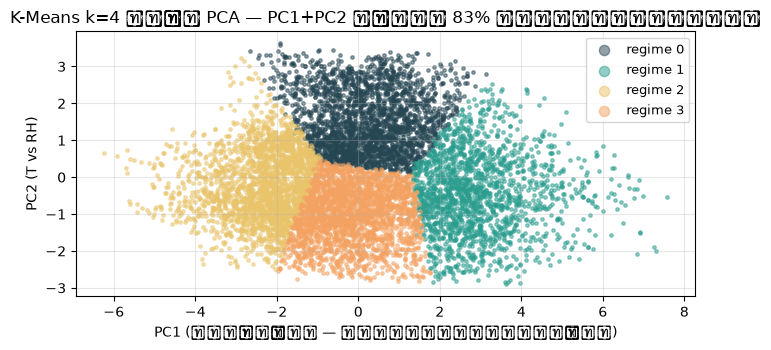

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2).fit(Xs)
Z = pca.transform(Xs)
evr = pca.explained_variance_ratio_
print(f"PC1 อธิบาย {evr[0]*100:.1f}% | PC2 อธิบาย {evr[1]*100:.1f}% | รวม {evr.sum()*100:.1f}%")

fig, ax = plt.subplots(figsize=(7, 3.6))
PALETTE = ["#264653", "#2a9d8f", "#e9c46a", "#f4a261", "#e76f51"]
for c in range(4):
    m = km_final.labels_ == c
    ax.scatter(Z[m, 0], Z[m, 1], s=6, color=PALETTE[c], label=f"regime {c}", alpha=0.5)
ax.set_xlabel("PC1 (รวมทุกช่อง — โหมดการตอบสนองร่วม)")
ax.set_ylabel("PC2 (T vs RH)")
ax.set_title(f"K-Means k=4 บนพื้น PCA — PC1+PC2 อธิบาย {evr.sum()*100:.0f}% ของความแปรปรวน")
ax.legend(markerscale=3, fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

# ภาพแบ่งชัดเป็นสองฝั่งซ้าย-ขวา (PC1) และซอยบน-ล่างอีกชั้น (PC2) — จะเข้าใจว่าทำไม ต้องดู **loadings** (น้ำหนักของแต่ละ feature ในแต่ละ PC) ถ้า feature ไหนน้ำหนักมาก แกนนั้นก็ "เป็นตัวแทน" ของ feature นั้น

shape: (2, 8)
┌─────────────┬───────────────┬──────────────┬──────────────┬─────────────┬───────┬────────┬─────┐
│ PT08.S1(CO) ┆ PT08.S2(NMHC) ┆ PT08.S3(NOx) ┆ PT08.S4(NO2) ┆ PT08.S5(O3) ┆ T     ┆ RH     ┆ PC  │
│ ---         ┆ ---           ┆ ---          ┆ ---          ┆ ---         ┆ ---   ┆ ---    ┆ --- │
│ f64         ┆ f64           ┆ f64          ┆ f64          ┆ f64         ┆ f64   ┆ f64    ┆ str │
╞═════════════╪═══════════════╪══════════════╪══════════════╪═════════════╪═══════╪════════╪═════╡
│ 0.46        ┆ 0.476         ┆ -0.425       ┆ 0.401        ┆ 0.45        ┆ 0.132 ┆ 0.0    ┆ PC1 │
│ -0.148      ┆ 0.03          ┆ 0.089        ┆ 0.227        ┆ -0.199      ┆ 0.686 ┆ -0.638 ┆ PC2 │
└─────────────┴───────────────┴──────────────┴──────────────┴─────────────┴───────┴────────┴─────┘


/tmp/ipykernel_45222/1047336056.py:18: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45222/1047336056.py:18: UserWarning: Glyph 3627 (\N{THAI CHARACTER HO HIP}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45222/1047336056.py:18: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45222/1047336056.py:18: UserWarning: Glyph 3651 (\N{THAI CHARACTER SARA AI MAIMUAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45222/1047336056.py:18: UserWarning: Glyph 3607 (\N{THAI CHARACTER THO THAHAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45222/1047336056.py:18: UserWarning: Glyph 3594 (\N{THAI CHARACTER CHO CHANG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45222/1047336056.py:18: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s

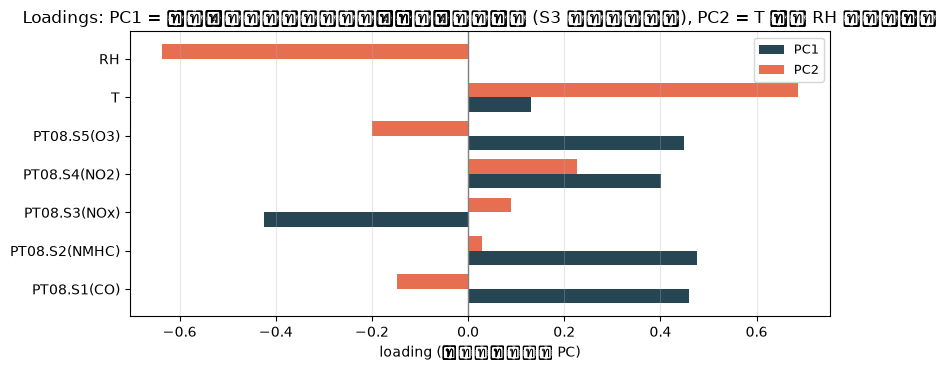

In [9]:
loadings = pl.DataFrame(
    np.round(pca.components_, 3),
    schema=FEATURES,
).with_columns(pl.Series("PC", ["PC1", "PC2"]))
print(loadings)

fig, ax = plt.subplots(figsize=(8.5, 3.8))
w = 0.38
ypos = np.arange(len(FEATURES))
ax.barh(ypos - w / 2, pca.components_[0], height=w, color="#264653", label="PC1")
ax.barh(ypos + w / 2, pca.components_[1], height=w, color="#e76f51", label="PC2")
ax.set_yticks(ypos, FEATURES)
ax.axvline(0, color="gray", lw=1)
ax.set_xlabel("loading (น้ำหนักใน PC)")
ax.set_title("Loadings: PC1 = ทุกช่องเซนเซอร์วิ่งด้วยกัน (S3 สวนทาง), PC2 = T กับ RH สวนกัน")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis="x")
fig.tight_layout()
plt.show()

# อ่าน loadings:
#
# - **PC1 (อธิบาย 58.9%):** S1, S2, S4, S5 น้ำหนักบวกใกล้กันหมด (~0.4–0.48) แต่ S3 ติดลบ (−0.43) — คือ **โหมดการตอบสนองร่วมของอุปกรณ์**: เมื่อมลพิษขึ้น ทุกช่องที่ "ไหม้" ก๊าซเดียวกันตอบสนองพร้อมกัน ส่วนช่อง NOx (S3) ตอบสวนทาง
# - **PC2 (อธิบาย 24.5%):** T +0.69 กับ RH −0.64 เกือบทรงตัว ส่วนเซนเซอร์แทบไม่มีน้ำหนัก — คือ **แกนอุณหภูมิ–ความชื้นล้วน ๆ** (อากาศร้อนกับชื้นสูงเป็นสองขั้วตรงข้าม)
#
# กล่าวอีกที: ข้อมูล 7 มิตินี้ยุบเป็น "โหมดเซนเซอร์ × โหมดสภาพอากาศ" สองแกนได้ 83% — เหตุผลที่เซนเซอร์ต้องสอบเทียบแยกตาม T/RH คือโครงสร้างนี้เอง

# ## 5. DBSCAN — ให้ density เป็นคนแบ่ง และให้มี "คนนอก"

# K-Means **บังคับทุกจุดให้มีเผ่า** (จุดที่แปลกที่สุดก็ต้องสังกัด centroid ไกล ๆ สักแห่ง) แบ่งเขตเป็นทรงกลม และต้องรู้ k ล่วงหน้า **DBSCAN** คิดต่าง: จุดที่อยู่หนาแน่นพร้อมเพื่อนนับเป็น **core** เดินต่อยอดกันเป็น cluster ทรงใดก็ได้ จุดที่ยืนโดดเดี่ยวกลายเป็น **noise (−1)** — สำหรับงานเมโทรโลยี noise คือรายชื่อ "ชั่วโมงที่สภาพแวดล้อมไม่อยู่ใน regime ไหนเลย" ซึ่ง K-Means มองไม่เห็น
#
# พารามิเตอร์สองตัว: `eps` (รัศมีเพื่อนบ้าน) กับ `min_samples` (จำนวนเพื่อนขั้นต่ำที่ทำให้เป็น core) — ฮิวริสติกที่นิยมคือ `min_samples ≥ 2 × จำนวน feature`; เราใช้ **10** (กัน cluster แตกเป็นเสี่ยง ๆ เมื่อ eps เล็ก แต่ยังไม่หนาจนกลืนก้อนเล็ก) ส่วน `eps` หาจาก **k-distance plot**: เรียงระยะทางถึงเพื่อนบ้านอันดับที่ 10 ของทุกจุดจากน้อยไปมาก จุดศอกของเส้นโค้งคือค่า eps ที่เหมาะ

/tmp/ipykernel_45222/2911817299.py:17: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45222/2911817299.py:17: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45222/2911817299.py:17: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45222/2911817299.py:17: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45222/2911817299.py:17: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45222/2911817299.py:17: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45222/2911817299.py:17: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sa

/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3621 (\N{THAI CHARACTER LO LING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3649 (\N{THAI CHARACTER SARA AE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/c

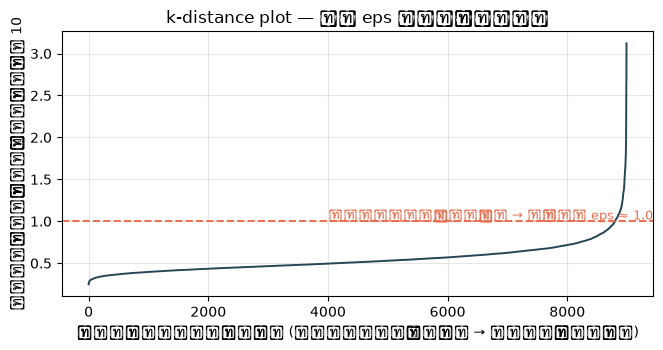

In [10]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

MIN_SAMPLES = 10
nn = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(Xs)
dists, _ = nn.kneighbors(Xs)
kdist = np.sort(dists[:, -1])          # ระยะถึงเพื่อนอันดับ 10 ของทุกจุด เรียงจากน้อยไปมาก

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(kdist, color="#264653", lw=1.4)
ax.axhline(1.0, color="#e76f51", ls="--", lw=1.4)
ax.annotate("ศอกของเส้นโค้ง → เลือก eps ≈ 1.0", xy=(4000, 1.02), color="#e76f51", fontsize=9)
ax.set_xlabel("จุดเรียงตามลำดับ (จากหนาแน่นสุด → โดดเดี่ยวสุด)")
ax.set_ylabel("ระยะถึงเพื่อนบ้านอันดับ 10")
ax.set_title("k-distance plot — หา eps จากจุดศอก")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

# เส้นโค้งราบยาว (คลัสเตอร์หลักหนาแน่นสม่ำเสมอ) แล้วชันขึ้นช่วงท้าย (จุดโดดเดี่ยว) — รอยหักของเส้นอยู่ราว 0.9–1.0 เรากวาด eps รอบนั้น 10 ค่าเพื่อดูว่าผลมั่นคงแค่ไหนก่อนตัดสินใจ

In [11]:
rows = []
for eps in np.arange(0.7, 1.65, 0.1):
    lab = DBSCAN(eps=float(eps), min_samples=MIN_SAMPLES).fit(Xs).labels_
    n_noise = int((lab == -1).sum())
    n_cl = len(set(lab)) - (1 if -1 in lab else 0)
    rows.append({"eps": round(float(eps), 1), "n_clusters": n_cl,
                 "n_noise": n_noise, "noise_%": round(n_noise / len(lab) * 100, 2)})
print(pl.DataFrame(rows))

shape: (10, 4)
┌─────┬────────────┬─────────┬─────────┐
│ eps ┆ n_clusters ┆ n_noise ┆ noise_% │
│ --- ┆ ---        ┆ ---     ┆ ---     │
│ f64 ┆ i64        ┆ i64     ┆ f64     │
╞═════╪════════════╪═════════╪═════════╡
│ 0.7 ┆ 3          ┆ 390     ┆ 4.34    │
│ 0.8 ┆ 1          ┆ 200     ┆ 2.22    │
│ 0.9 ┆ 2          ┆ 101     ┆ 1.12    │
│ 1.0 ┆ 2          ┆ 54      ┆ 0.6     │
│ 1.1 ┆ 1          ┆ 43      ┆ 0.48    │
│ 1.2 ┆ 1          ┆ 33      ┆ 0.37    │
│ 1.3 ┆ 1          ┆ 29      ┆ 0.32    │
│ 1.4 ┆ 2          ┆ 13      ┆ 0.14    │
│ 1.5 ┆ 1          ┆ 8       ┆ 0.09    │
│ 1.6 ┆ 1          ┆ 5       ┆ 0.06    │
└─────┴────────────┴─────────┴─────────┘


# แนวโน้มสมเหตุสมผล: **eps ยิ่งใหญ่ → noise ยิ่งหาย** (รัศมีกว้าง ใคร ๆ ก็มีเพื่อน — ที่ eps 1.5 เหลือ noise ~0.1%) และยิ่งเล็ก → noise พุ่งชันและเริ่มมีก้อนย่อยแตกออก (eps 0.7 noise ถึง 390 ชั่วโมง ~4%) เลือก **eps = 1.0** ตรงรอยหักของ k-distance: ได้ cluster ใหญ่หลัก + ก้อนเล็กที่แยกตัวจริง + noise ~0.6% — แล้วดูว่า DBSCAN หาอะไรเจอ

In [12]:
db = DBSCAN(eps=1.0, min_samples=MIN_SAMPLES).fit(Xs)
clean = clean.with_columns(pl.Series("dbscan", db.labels_))
n_noise = int((db.labels_ == -1).sum())
n_cl = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
print(f"clusters = {n_cl}, noise = {n_noise} ชั่วโมง ({n_noise / len(db.labels_) * 100:.2f}%)")
with pl.Config(tbl_width_chars=250):
    print(clean.group_by("dbscan").agg(
        pl.len().alias("n_hours"),
        pl.col("T").mean().round(1),
        pl.col("RH").mean().round(1),
        pl.col("ts").min().dt.date().alias("from"),
        pl.col("ts").max().dt.date().alias("to"),
    ).sort("dbscan"))

clusters = 2, noise = 54 ชั่วโมง (0.60%)
shape: (3, 6)
┌────────┬─────────┬──────┬──────┬────────────┬────────────┐
│ dbscan ┆ n_hours ┆ T    ┆ RH   ┆ from       ┆ to         │
│ ---    ┆ ---     ┆ ---  ┆ ---  ┆ ---        ┆ ---        │
│ i64    ┆ u32     ┆ f64  ┆ f64  ┆ date       ┆ date       │
╞════════╪═════════╪══════╪══════╪════════════╪════════════╡
│ -1     ┆ 54      ┆ 16.3 ┆ 50.6 ┆ 2004-03-15 ┆ 2005-02-14 │
│ 0      ┆ 8920    ┆ 18.3 ┆ 49.2 ┆ 2004-03-10 ┆ 2005-04-04 │
│ 1      ┆ 17      ┆ 10.5 ┆ 79.6 ┆ 2004-12-01 ┆ 2004-12-02 │
└────────┴─────────┴──────┴──────┴────────────┴────────────┘


# ผลน่าสนใจสามชั้น:
#
# 1. **cluster ใหญ่ (8,920 ชั่วโมง)** = ชีวิตประจำวันทั้งหมด — กับ DBSCAN ข้อมูลนี้เป็นก้อนหนาแน่นก้อนเดียว ต่างจาก K-Means ที่บังคับซอยเป็น 4 ทรงกลม
# 2. **cluster เล็ก (17 ชั่วโมง)** รวมกันหมดเป็นคืนวันที่ **1–2 ธันวาคม 2004** — T ≈ 10 °C แต่ RH ≈ 78–82% (ชื้นผิดปกติสำหรับคืนหนาว) ลักษณะเป็นหมอก/ฝนคืนนั้น — เซนเซอร์ metal-oxide ไวต่อความชื้นมาก ชั่วโมงพวกนี้จึง "ลอย" ออกจากแถวเพื่อน
# 3. **noise 54 ชั่วโมง (~0.6%)** กระจายเป็นเหตุการณ์สั้น ๆ — สภาพที่เครื่องวัดไม่เคยอยู่นานพอจะเป็น regime
#
# **K-Means vs DBSCAN ในหนึ่งบรรทัด:** K-Means ตอบคำถาม "ข้อมูลมีกี่ regime และแต่ละ regime หน้าตาเป็นอย่างไร" (partition + centroid ใช้ตั้งชื่อได้) ส่วน DBSCAN ตอบ "มีชั่วโมงไหนไม่อยู่ใน regime ไหนเลย" (density + noise ใช้ตรวจความผิดปกติได้) — เครื่องมือต่างจุดประสงค์ ไม่ใช่แข่งกัน

# ## 6. Regime บนแกนเวลา — ปิดวงกับเรื่อง T/RH และ traffic

# คำถามปิดท้าย: regime ที่ K-Means หาได้ สัมพันธ์กับ **รอบวัน** และ **ฤดูกาล** จริงหรือไม่ — พล็อตสัดส่วน cluster ต่อชั่วโมงของวัน และจำนวนชั่วโมงของแต่ละ cluster ต่อเดือน

/tmp/ipykernel_45222/592361720.py:37: UserWarning: Glyph 3594 (\N{THAI CHARACTER CHO CHANG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45222/592361720.py:37: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45222/592361720.py:37: UserWarning: Glyph 3650 (\N{THAI CHARACTER SARA O}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45222/592361720.py:37: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45222/592361720.py:37: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45222/592361720.py:37: UserWarning: Glyph 3586 (\N{THAI CHARACTER KHO KHAI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45222/592361720.py:37: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
 

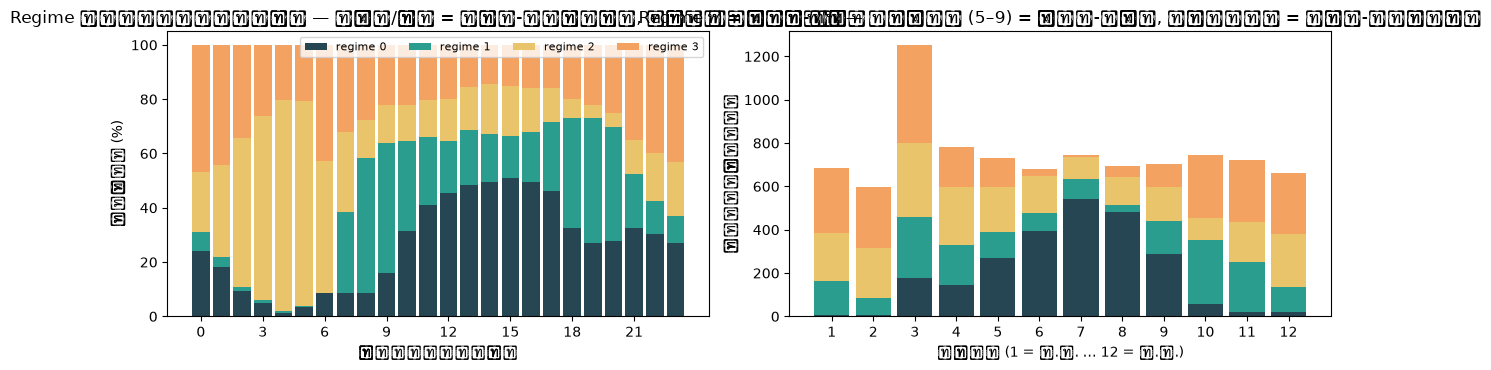

In [13]:
hour_pct = (
    clean.with_columns(pl.col("ts").dt.hour().alias("hour"))
    .group_by("hour", "cluster").len()
    .pivot(on="cluster", index="hour", values="len")
    .sort("hour").fill_null(0)
)
cl_cols = sorted((c for c in hour_pct.columns if c != "hour"), key=int)  # ชื่อคอลัมน์หลัง pivot เป็น string
hour_pct = hour_pct.with_columns(
    (pl.col(c) / pl.sum_horizontal([pl.col(c2) for c2 in cl_cols]) * 100) for c in cl_cols
)

month_cnt = (
    clean.with_columns(pl.col("ts").dt.month().alias("month"))
    .group_by("month", "cluster").len()
    .pivot(on="cluster", index="month", values="len")
    .sort("month").fill_null(0)
)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8))
bottom = np.zeros(24)
for c in cl_cols:
    axes[0].bar(hour_pct["hour"], hour_pct[c], bottom=bottom, color=PALETTE[int(c)], label=f"regime {c}", width=0.85)
    bottom += hour_pct[c].to_numpy()
axes[0].set_xlabel("ชั่วโมงของวัน")
axes[0].set_ylabel("สัดส่วน (%)")
axes[0].set_title("Regime ตามเวลาของวัน — เช้า/ค่ำ = เย็น-มลพิษสูง, เที่ยง = ร้อน-แห้ง")
axes[0].set_xticks(range(0, 24, 3))
bottom = np.zeros(12)
for c in cl_cols:
    axes[1].bar(month_cnt["month"], month_cnt[c], bottom=bottom, color=PALETTE[int(c)], label=f"regime {c}", width=0.85)
    bottom += month_cnt[c].to_numpy()
axes[1].set_xlabel("เดือน (1 = ม.ค. … 12 = ธ.ค.)")
axes[1].set_ylabel("จำนวนชั่วโมง")
axes[1].set_title("Regime ตามเดือน — ฤดูร้อน (5–9) = ร้อน-แห้ง, ฤดูหนาว = เย็น-มลพิษสูง")
axes[1].set_xticks(range(1, 13))
axes[0].legend(fontsize=8, ncol=4)
fig.tight_layout()
plt.show()

# ภาพยืนยันทุกอย่างที่เราอ่านจาก centroid:
#
# - **รอบวัน:** regime "เย็น-มลพิษสูง" (สีเขียว) ครองช่วง 07:00–09:00 และ 18:00–21:00 พอดี **rush hour** — มลพิษจากรถ + อากาศเย็นตอนเช้า/ค่ำ; regime "ร้อน-แห้ง" (สีน้ำเงินเข้ม) ครองเที่ยงถึงบ่าย; regime "คืนลึก" (เหลือง) ครอง 02:00–06:00
# - **ฤดูกาล:** regime "ร้อน-แห้ง" เกาะกลุ่มเดือน 5–9 (ฤดูร้อนอิตาลี) ส่วน regime เย็นทั้งสองเกาะเดือน 10–2
#
# นี่คือบทสรุปเมโทรโลยีของโมดูล: **regime ที่ clustering เจอ ไม่ได้เป็นนามธรรมทางคณิตศาสตร์ — มันคือตารางเวลาจริงของสภาพแวดล้อมที่เครื่องมือต้องเผชิญ** ห้องปฏิบัติการที่อยากสอบเทียบเซนเซอร์นี้ให้แม่น จึงควรมีโมเดลการตอบสนองแยก (หรือแยกเทอมแก้ไข) ตาม regime ที่ตรงกับฤดูและชั่วโมงเหล่านี้ และควรเก็บชั่วโมง noise/ก้อนเล็กของ DBSCAN ไว้ตรวจเป็นกรณีพิเศษ

# ## 7. สรุปโมดูล
#
# - **Scale ก่อนเสมอ** — K-Means/DBSCAN ใช้ระยะทาง คอลัมน์สเกลใหญ่ข่มทุกอย่าง (std ต่างกัน ~45 เท่าในข้อมูลนี้)
# - **เลือก k ด้วยสองเกณฑ์ + การตีความ** — elbow บอกจุดหม่อม สูงสุด silhouette อาจหยาบเกินงาน (k=2 ที่นี่) เลือก k=4 เพราะตั้งชื่อ regime แต่ละอันได้จริง
# - **Centroid ต้องแปลงกลับหน่วยจริง** ก่อนตีความ — `inverse_transform` แล้วอ่านเป็น "ใบหน้า" ของ regime
# - **PCA ช่วยให้เห็น 7 มิติบนกระดาษ** — PC1 = โหมดการตอบสนองร่วมของเซนเซอร์ (58.9%), PC2 = แกน T–RH (24.5%) รวม 83%
# - **DBSCAN ให้สิ่งที่ K-Means ให้ไม่ได้: รายชื่อ noise** — 17 ชั่วโมงของคืนหมอก 1–2 ธ.ค. 2004 กับ noise อีก ~0.6% คือ "ชั่วโมงนอก regime" ที่งานสอบเทียบต้องแยกตรวจ
# - Regime = สภาพแวดล้อมจริงบนแกนเวลา (rush hour, ฤดู) — clustering แปลง 7 คอลัมน์ดิบให้กลายเป็น "แผนที่สภาพการใช้งาน" ของเครื่องมือ